# CW-1 Analysis of Ethereum

## Dataset overview

Ethereum is a blockchain based distributed computing platform where 
users may exchange currency (Ether), provide or purchase services (smart
 contracts), mint their own coinage (tokens), as well as other 
applications. The Ethereum network is fully decentralised, managed by 
public-key cryptography, peer-to-peer networking, and proof-of-work to 
process/verify transactions.

## Dataset Schema - blocks

**number**: The block number

**hash**: Hash of the block

**parent_hash**: Hash of the parent of the block

**nonce**: Nonce that satisfies the difficulty target

**sha3_uncles**: Combined has of all uncles for a given parent

**logs_bloom**: Data structure containing event logs

**transactions_root**: Root hash of the transactions in the payload

**state_root**: Root hash of the state object

**receipts_root**: hash of the transaction receipts tree

**miner**: The address of the beneficiary to whom the mining rewards were given

**difficulty**: Integer of the difficulty for this block

**total_difficulty**: Total difficulty of the chain until this block

**size**: The size of this block in bytes

**extra_data**: Arbitrary additional data as raw bytes

**gas_limit**:  The maximum gas allowed in this block

**gas_used**:   The total used gas by all transactions in this block

**timestamp**:  The timestamp for when the block was collated

**transaction_count**:  The number of transactions in the block

**base_fee_per_gas**: Base fee value

In [24]:
import pandas as pd
df=pd.read_csv("blocks.csv")

In [25]:
df

,number,hash,miner,difficulty,size,gas_limit,gas_used,timestamp,transaction_count
0,4776199,0x9172600443ac88e490f17302cbf83572719882d4e363...,0x5a0b54d5dc17e0aadc383d2db43b0a0d3e029c4c,1765656009004680,9773,7995996,2042230,1513937536,62
1,4776200,0x1fb1d4a2f5d2a61f7317819bfacb4820d5472e581893...,0xea674fdde714fd979de3edf0f56aa9716b898ec8,1765656009037448,15532,8000029,4385719,1513937547,101
2,4776201,0xe633b6dca01d0850a289f4f5a5d89da5700bb89f0d5d...,0x829bd824b016326a401d083b33d092293333a830,1765656009070216,14033,8000000,7992282,1513937564,99
3,4776202,0x2ec4b8235923a59e2c805c42d554795829bf47e4d7db...,0x52bc44d5378309ee2abf1539bf71de1b7d7be3b5,1765656009102984,29386,8000029,7851362,1513937573,238
4,4776203,0x41f604b680e98d9e686380f3c2976631fed34693d479...,0xea674fdde714fd979de3edf0f56aa9716b898ec8,1765656009135752,28954,8000029,7608807,1513937582,218
...,...,...,...,...,...,...,...,...,...
5997,4781996,0xdbf7e35a725eccc32187d2385181077cbfc45c6fec18...,0x52bc44d5378309ee2abf1539bf71de1b7d7be3b5,1800454275900794,10502,8000029,2273132,1514024377,77
5998,4781997,0xea4f15dbbe822a1f249d798207a13aa7ef45ccf2fb60...,0x52bc44d5378309ee2abf1539bf71de1b7d7be3b5,1801333403997966,2595,8000029,895536,1514024379,12
5999,4781998,0xf7703bd13c43b7b6a9713dce986828e679ffad0b7892...,0x2a65aca4d5fc5b5c859090a6c34d164135398226,1800453846704564,28973,7992222,7948384,1514024404,174
6000,4781999,0x4d6deb8000dee84dc46f01f7c081696635641a752def...,0x5a0b54d5dc17e0aadc383d2db43b0a0d3e029c4c,1802212102447004,16693,7984452,4441039,1514024410,112


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6002 entries, 0 to 6001
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   number             6002 non-null   int64 
 1   hash               6002 non-null   object
 2   miner              6002 non-null   object
 3   difficulty         6002 non-null   int64 
 4   size               6002 non-null   int64 
 5   gas_limit          6002 non-null   int64 
 6   gas_used           6002 non-null   int64 
 7   timestamp          6002 non-null   int64 
 8   transaction_count  6002 non-null   int64 
dtypes: int64(7), object(2)
memory usage: 422.1+ KB


In [27]:
df.describe()

,number,difficulty,size,gas_limit,gas_used,timestamp,transaction_count
count,6.002000e+03,6.002000e+03,6002.000000,6.002000e+03,6.002000e+03,6.002000e+03,6002.000000
mean,4.779000e+06,1.741861e+15,27570.620460,7.995388e+06,7.206579e+06,1.513980e+09,172.625791
std,1.732772e+03,2.918678e+13,9239.269954,9.274924e+03,1.809166e+06,2.614711e+04,84.464726
min,4.775999e+06,1.692814e+15,530.000000,7.930173e+06,0.000000e+00,1.513935e+09,0.000000
25%,4.777499e+06,1.715351e+15,22739.750000,7.992222e+06,7.895626e+06,1.513958e+09,107.000000
50%,4.779000e+06,1.738658e+15,28955.000000,7.999992e+06,7.979506e+06,1.513980e+09,163.500000
75%,4.780500e+06,1.763078e+15,34384.750000,8.000029e+06,7.989702e+06,1.514003e+09,234.000000
max,4.782000e+06,1.824985e+15,55605.000000,8.019522e+06,8.014973e+06,1.514024e+09,380.000000


In [28]:
import pandas as pd

# convert the Unix timestamp column to a datetime column in the desired format
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s').dt.strftime('%d:%m:%Y %H:%M:%S')
# convert the datetime column to a datetime format
df['datetime'] = pd.to_datetime(df['datetime'], format='%d:%m:%Y %H:%M:%S')
# extract the month value using the dt.month property
df['month'] = df['datetime'].dt.month
df

,number,hash,miner,difficulty,size,gas_limit,gas_used,timestamp,transaction_count,datetime,month
0,4776199,0x9172600443ac88e490f17302cbf83572719882d4e363...,0x5a0b54d5dc17e0aadc383d2db43b0a0d3e029c4c,1765656009004680,9773,7995996,2042230,1513937536,62,2017-12-22 10:12:16,12
1,4776200,0x1fb1d4a2f5d2a61f7317819bfacb4820d5472e581893...,0xea674fdde714fd979de3edf0f56aa9716b898ec8,1765656009037448,15532,8000029,4385719,1513937547,101,2017-12-22 10:12:27,12
2,4776201,0xe633b6dca01d0850a289f4f5a5d89da5700bb89f0d5d...,0x829bd824b016326a401d083b33d092293333a830,1765656009070216,14033,8000000,7992282,1513937564,99,2017-12-22 10:12:44,12
3,4776202,0x2ec4b8235923a59e2c805c42d554795829bf47e4d7db...,0x52bc44d5378309ee2abf1539bf71de1b7d7be3b5,1765656009102984,29386,8000029,7851362,1513937573,238,2017-12-22 10:12:53,12
4,4776203,0x41f604b680e98d9e686380f3c2976631fed34693d479...,0xea674fdde714fd979de3edf0f56aa9716b898ec8,1765656009135752,28954,8000029,7608807,1513937582,218,2017-12-22 10:13:02,12
...,...,...,...,...,...,...,...,...,...,...,...
5997,4781996,0xdbf7e35a725eccc32187d2385181077cbfc45c6fec18...,0x52bc44d5378309ee2abf1539bf71de1b7d7be3b5,1800454275900794,10502,8000029,2273132,1514024377,77,2017-12-23 10:19:37,12
5998,4781997,0xea4f15dbbe822a1f249d798207a13aa7ef45ccf2fb60...,0x52bc44d5378309ee2abf1539bf71de1b7d7be3b5,1801333403997966,2595,8000029,895536,1514024379,12,2017-12-23 10:19:39,12
5999,4781998,0xf7703bd13c43b7b6a9713dce986828e679ffad0b7892...,0x2a65aca4d5fc5b5c859090a6c34d164135398226,1800453846704564,28973,7992222,7948384,1514024404,174,2017-12-23 10:20:04,12
6000,4781999,0x4d6deb8000dee84dc46f01f7c081696635641a752def...,0x5a0b54d5dc17e0aadc383d2db43b0a0d3e029c4c,1802212102447004,16693,7984452,4441039,1514024410,112,2017-12-23 10:20:10,12


In [29]:
df.datetime

0      2017-12-22 10:12:16
1      2017-12-22 10:12:27
2      2017-12-22 10:12:44
3      2017-12-22 10:12:53
4      2017-12-22 10:13:02
               ...        
5997   2017-12-23 10:19:37
5998   2017-12-23 10:19:39
5999   2017-12-23 10:20:04
6000   2017-12-23 10:20:10
6001   2017-12-23 10:20:36
Name: datetime, Length: 6002, dtype: datetime64[ns]

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6002 entries, 0 to 6001
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   number             6002 non-null   int64         
 1   hash               6002 non-null   object        
 2   miner              6002 non-null   object        
 3   difficulty         6002 non-null   int64         
 4   size               6002 non-null   int64         
 5   gas_limit          6002 non-null   int64         
 6   gas_used           6002 non-null   int64         
 7   timestamp          6002 non-null   int64         
 8   transaction_count  6002 non-null   int64         
 9   datetime           6002 non-null   datetime64[ns]
 10  month              6002 non-null   int64         
dtypes: datetime64[ns](1), int64(8), object(2)
memory usage: 515.9+ KB


In [31]:
df.describe()

,number,difficulty,size,gas_limit,gas_used,timestamp,transaction_count,month
count,6.002000e+03,6.002000e+03,6002.000000,6.002000e+03,6.002000e+03,6.002000e+03,6002.000000,6002.0
mean,4.779000e+06,1.741861e+15,27570.620460,7.995388e+06,7.206579e+06,1.513980e+09,172.625791,12.0
std,1.732772e+03,2.918678e+13,9239.269954,9.274924e+03,1.809166e+06,2.614711e+04,84.464726,0.0
min,4.775999e+06,1.692814e+15,530.000000,7.930173e+06,0.000000e+00,1.513935e+09,0.000000,12.0
25%,4.777499e+06,1.715351e+15,22739.750000,7.992222e+06,7.895626e+06,1.513958e+09,107.000000,12.0
50%,4.779000e+06,1.738658e+15,28955.000000,7.999992e+06,7.979506e+06,1.513980e+09,163.500000,12.0
75%,4.780500e+06,1.763078e+15,34384.750000,8.000029e+06,7.989702e+06,1.514003e+09,234.000000,12.0
max,4.782000e+06,1.824985e+15,55605.000000,8.019522e+06,8.014973e+06,1.514024e+09,380.000000,12.0


In [32]:
df.describe()

,number,difficulty,size,gas_limit,gas_used,timestamp,transaction_count,month
count,6.002000e+03,6.002000e+03,6002.000000,6.002000e+03,6.002000e+03,6.002000e+03,6002.000000,6002.0
mean,4.779000e+06,1.741861e+15,27570.620460,7.995388e+06,7.206579e+06,1.513980e+09,172.625791,12.0
std,1.732772e+03,2.918678e+13,9239.269954,9.274924e+03,1.809166e+06,2.614711e+04,84.464726,0.0
min,4.775999e+06,1.692814e+15,530.000000,7.930173e+06,0.000000e+00,1.513935e+09,0.000000,12.0
25%,4.777499e+06,1.715351e+15,22739.750000,7.992222e+06,7.895626e+06,1.513958e+09,107.000000,12.0
50%,4.779000e+06,1.738658e+15,28955.000000,7.999992e+06,7.979506e+06,1.513980e+09,163.500000,12.0
75%,4.780500e+06,1.763078e+15,34384.750000,8.000029e+06,7.989702e+06,1.514003e+09,234.000000,12.0
max,4.782000e+06,1.824985e+15,55605.000000,8.019522e+06,8.014973e+06,1.514024e+09,380.000000,12.0


<BarContainer object of 10 artists>

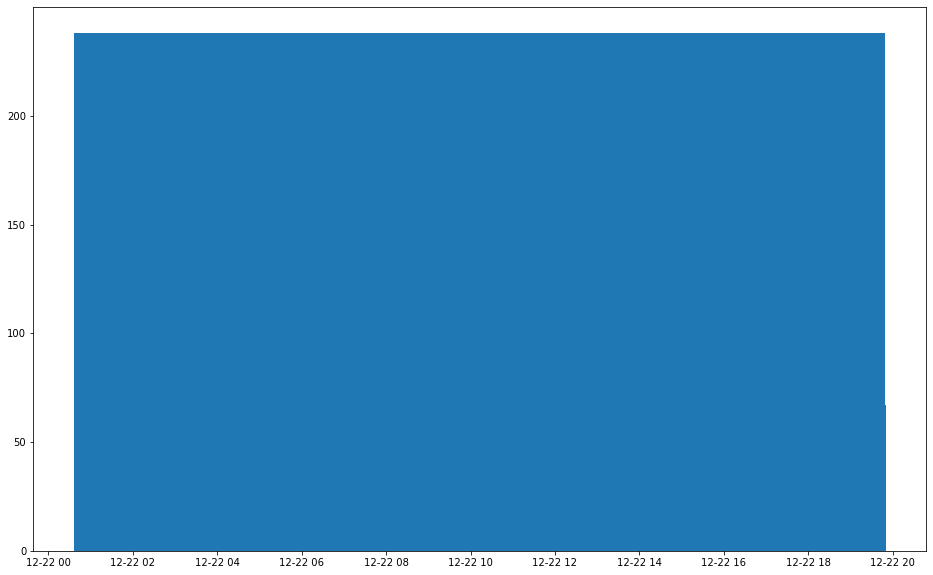

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,10))
plt.bar(df.datetime[:10],df.transaction_count[:10])

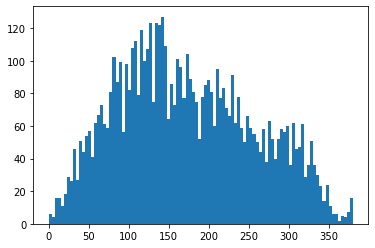

In [43]:
plt.hist(df.transaction_count,bins=100);

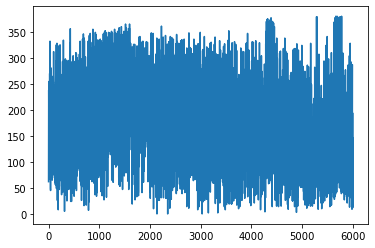

In [44]:
plt.plot(df.transaction_count);

## Part B. Top Ten Most Popular Services (25%)

Evaluate the top 10 smart contracts by total Ether received. You will need to join **address** field in the contracts dataset to the **to_address** in the transactions dataset to determine how much ether a contract has received.

In [45]:
contract_df=pd.read_csv("contract.csv")

In [49]:
contract_df.columns

Index(['address', 'is_erc20', 'is_erc721', 'block_number', 'block_timestamp'], dtype='object')

In [47]:
trans_df=pd.read_csv("transactions.csv")

In [50]:
trans_df.columns

Index(['block_number', 'from_address', 'to_address', 'value', 'gas',
       'gas_price', 'block_timestamp'],
      dtype='object')

In [51]:
import pandas as pd

# Load the two datasets
contracts = pd.read_csv('contract.csv')
transactions = pd.read_csv('transactions.csv')



# Group the transactions by contract address and sum the 'value' column to get the total Ether received by each contract
total_received = merged.groupby('address')['value'].sum().reset_index()

# Sort the contracts by total Ether received in descending order and return the top 10
top_10 = total_received.sort_values(by='value', ascending=False).head(10)

# Print the top 10 contracts
print(top_10)


                                      address         value
0  0x996035cae22cd90ae5e993d0832cfac4db239109  4.477970e+15
1  0xcd9a70f197238f0ee7045080368dc7d07502b353  2.100000e+15


In [53]:
contracts = pd.read_csv('contract.csv')
transactions = pd.read_csv('transactions.csv')

In [54]:
# Join the two datasets on the 'address' column in 'contracts' and 'to_address' column in 'transactions'
merged = pd.merge(contracts, transactions, how='inner', left_on='address', right_on='to_address')

In [55]:
merged 

,address,is_erc20,is_erc721,block_number_x,block_timestamp_x,block_number_y,from_address,to_address,value,gas,gas_price,block_timestamp_y
0,0xcd9a70f197238f0ee7045080368dc7d07502b353,False,False,7314564,2019-03-06 08:06:22 UTC,2280517,0x9535b2e7faaba5288511d89341d94a38063a349b,0xcd9a70f197238f0ee7045080368dc7d07502b353,2.100000e+15,90000,20000000000,1474180221
1,0x996035cae22cd90ae5e993d0832cfac4db239109,False,False,7314564,2019-03-06 08:06:22 UTC,2280374,0xcd88e0e0c455345833ce31c5452c1c37f4b4c438,0x996035cae22cd90ae5e993d0832cfac4db239109,4.477970e+15,21000,20000000000,1474178142
